# Opt2: Vectorized pandas operators

Built on the baseline, this version replaces the row-by-row Python loops in the
backtester with **pandas vectorized built-ins**:

- `ts_mean / ts_std / ts_max / ts_min` → `DataFrame.rolling(d).agg()` (single C-level pass)
- `ts_delta` → `x - x.shift(d)` (vectorized across the whole panel)
- `ts_corr` → rolling pairwise correlation per ticker, vectorized
- `rank` / `zscore` → `rank(axis=1, pct=True)` / vectorized cross-sectional standardization
- `sign / log / abs / power` → NumPy ufuncs applied to the whole DataFrame

Factor results are **numerically identical** to the baseline (within floating-point
tolerance); only the execution path changes. The expected speedup for
`compute_all_factors` is ~30–90× because each operator now issues a single
C-level pandas/NumPy call instead of 752 Python-loop iterations.

Remember to rotate your Anthropic API key — the one embedded in the notebook
should be moved to an environment variable (`os.environ["ANTHROPIC_API_KEY"]`).


In [1]:
import os
import re
import json
import ast
import time
import warnings
import pickle

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm


In [2]:
# Initialize timing dictionary to collect execution times
timing = {}

## Part 1: Data Loading

In [3]:
def get_tickers(n_stocks):
    df = pd.read_csv("../data/sp500_tickers.csv")
    tickers = df["ticker"].tolist()
    return tickers[:n_stocks]

def load_sp500_data(start, end, n_stocks, cache_path="../data/sp500_cache.pkl"):
    if os.path.exists(cache_path):
        print("Cache found, loading from disk...")
        with open(cache_path, "rb") as f:
            data = pickle.load(f)
        print(f"Loaded: {data['close'].shape[0]} days x {data['close'].shape[1]} stocks")
        return data
 
    import yfinance as yf
    tickers = get_tickers(n_stocks)
    # --- Download price data from Yahoo Finance ---
    print(f"Downloading data from {start} to {end} ...")
    raw = yf.download(tickers, start=start, end=end, auto_adjust=True, progress=True)
 
    # --- Extract each field into its own DataFrame ---
    close  = raw["Close"].ffill().bfill()
    open_  = raw["Open"].ffill().bfill()
    high   = raw["High"].ffill().bfill()
    low    = raw["Low"].ffill().bfill()
    volume = raw["Volume"].ffill().bfill()
 
    # Drop stocks that are missing more than 10% of data
    min_rows = int(len(close) * 0.9)
    close = close.dropna(thresh=min_rows, axis=1)
 
    # Keep only the stocks that survived the filter
    valid = close.columns
    open_, high, low, volume = open_[valid], high[valid], low[valid], volume[valid]
 
    # --- Derive extra fields needed for factor calculation ---
    vwap    = (high + low + close) / 3          # typical price, proxy for VWAP
    returns = close.pct_change().fillna(0)      # daily return
    adv20   = volume.rolling(20).mean().bfill() # 20-day average daily volume
 
    print(f"Done: {close.shape[0]} days x {close.shape[1]} stocks")
 
    data = {
        "open": open_, "high": high, "low": low,
        "close": close, "volume": volume,
        "vwap": vwap, "returns": returns, "adv20": adv20,
    }
 
    # --- Save to cache ---
    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
    with open(cache_path, "wb") as f:
        pickle.dump(data, f)
    print(f"Saved to {cache_path}")
 
    return data

In [4]:
data = load_sp500_data(
    start    = "2023-01-01",
    end      = "2026-01-01",
    n_stocks = 500,
)
print(data["close"].head(3))

Cache found, loading from disk...
Loaded: 752 days x 483 stocks
Ticker               A    AAL        AAPL        ABBV       ABNB         ABT  \
Date                                                                           
2023-01-03  146.749939  12.74  123.096016  144.322632  84.900002  102.849213   
2023-01-04  148.344147  13.59  124.365662  145.486938  88.720001  104.379097   
2023-01-05  148.774521  13.99  123.046822  145.309204  87.709999  103.994286   

Ticker           ACGL         ACN        ADBE         ADI  ...         WTW  \
Date                                                       ...               
2023-01-03  59.393120  258.138916  336.920013  153.730545  ...  235.955490   
2023-01-04  59.687901  257.260101  341.410004  157.004852  ...  237.216171   
2023-01-05  59.849552  251.185394  328.440002  151.118698  ...  237.168060   

Ticker             WY       WYNN        XEL        XOM         XYL  \
Date                                                                 
2023

## Part 2: Load cached factors

Reuses the 216 factors generated and cached during the baseline run. No API call is made, so Opt2's factor set is byte-identical to baseline's — speedup comparisons are apples-to-apples.

In [5]:
# Load the factors cached from the baseline run.
# No API call is made — we reuse the exact same 216 factors so that
# Opt2's results are directly comparable to the baseline's.
with open("../results/evaluation/factors.json", "r") as f:
    factors = json.load(f)

print(f"Loaded {len(factors)} factors from cache")
for i, f in enumerate(factors[:5], 1):
    print(f"  {i}. {f['factor']}")
    print(f"     → {f['description']}")
print(f"  ... ({len(factors) - 5} more)")


Loaded 216 factors from cache
  1. rank(ts_mean(close, 5) - ts_mean(close, 20))
     → Rank of the difference between 5-day and 20-day closing price moving averages — captures short-term vs long-term price trend momentum.
  2. rank(ts_mean(returns, 20) / ts_std(returns, 20))
     → Rank of 20-day average daily return divided by 20-day standard deviation of returns — captures volatility-adjusted momentum (Sharpe-ratio like).
  3. rank(close - ts_min(low, 20))
     → Rank of today's closing price relative to the 20-day minimum low price — identifies stocks consistently closing significantly above their recent lows, indicating upward momentum.
  4. rank(ts_delta(vwap, 10) * (volume / adv20))
     → Rank of 10-day VWAP change multiplied by today's volume relative to its 20-day average volume — combines VWAP momentum with volume confirmation.
  5. rank(ts_mean(close - open, 5))
     → Rank of the 5-day average of (closing price - opening price) — captures consistent daily intra-day upward m

## Part 3: Backtesting framework (Opt2 — vectorized pandas)

In [6]:
class Opt2Backtester:
    """
    Vectorized pandas implementation of the baseline operators.

    Design choices:
      - All time-series ops use DataFrame.rolling / .shift, which dispatch to
        Cython under the hood and avoid per-row Python overhead.
      - Cross-sectional ops (rank, zscore) use axis=1 reductions.
      - ts_corr uses rolling().corr() pairwise per ticker (same-ticker x vs y),
        matching baseline semantics: correlation between two series of the same
        stock over a rolling window.
      - min_periods=d matches baseline's NaN-padding in the first d-1 rows.
      - sign/log use np.sign / np.log directly on the DataFrame — pandas
        preserves index/columns automatically.
    """

    def __init__(self, data):
        self.data = data

    # ── Time-series operators (vectorized: one C-level call per operator) ────

    def ts_mean(self, x, d):
        return x.rolling(d, min_periods=d).mean()

    def ts_std(self, x, d):
        return x.rolling(d, min_periods=d).std()

    def ts_delta(self, x, d):
        return x - x.shift(d)

    def ts_max(self, x, d):
        return x.rolling(d, min_periods=d).max()

    def ts_min(self, x, d):
        return x.rolling(d, min_periods=d).min()

    def ts_corr(self, x, y, d):
        # Rolling same-ticker correlation between x and y over a d-day window.
        # DataFrame.rolling(d).corr(other) computes this pairwise per column,
        # replacing the baseline's O(T*N) Python double loop.
        result = x.rolling(d, min_periods=d).corr(y)
        # Match baseline semantics:
        #   - Warmup rows (first d-1): stay NaN
        #   - Post-warmup rows where a window had zero std: baseline returned 0.0.
        #     pandas' rolling().corr() returns NaN for those too — so fill only
        #     post-warmup NaNs with 0.0.
        result = result.replace([float("inf"), float("-inf")], 0.0)
        result.iloc[d - 1 :] = result.iloc[d - 1 :].fillna(0.0).values
        return result

    # ── Cross-sectional operators (vectorized across stocks per date) ────────

    def rank(self, x):
        # Percentile rank each row across stocks; NaNs stay NaN (baseline behavior).
        return x.rank(axis=1, pct=True)

    def zscore(self, x):
        mu = x.mean(axis=1)
        sigma = x.std(axis=1)
        # Broadcast along axis=0 (rows): subtract each day's mean, divide by std.
        # Where sigma == 0, baseline returned 0.0 → mirror that by filling inf/NaN.
        z = x.sub(mu, axis=0).div(sigma, axis=0)
        return z.replace([float("inf"), float("-inf")], 0.0).fillna(0.0)

    # ── Math operators (ufuncs on the whole DataFrame) ───────────────────────

    def sign(self, x):
        # Match baseline quirk: baseline's row-by-row sign implementation falls
        # into its `else: 0.0` branch when the input is NaN (NaN > 0 and
        # NaN < 0 both evaluate to False), so NaN → 0.0. np.sign(NaN) = NaN,
        # which would differ, so we explicitly fill NaN with 0.0 here.
        return np.sign(x).fillna(0.0)

    def log(self, x):
        # Baseline clamped to >= 1e-9 before taking log to avoid -inf.
        return np.log(x.clip(lower=1e-9))

    def abs(self, x):
        return x.abs()

    def power(self, x, n):
        return x ** n

    # ── Factor computation (same eval-based interface as baseline) ──────────

    def compute_factor(self, expr):
        ctx = {
            "open":    self.data["open"],
            "high":    self.data["high"],
            "low":     self.data["low"],
            "close":   self.data["close"],
            "volume":  self.data["volume"],
            "vwap":    self.data["vwap"],
            "returns": self.data["returns"],
            "adv20":   self.data["adv20"],
            "ts_mean":  self.ts_mean,
            "ts_std":   self.ts_std,
            "ts_delta": self.ts_delta,
            "ts_max":   self.ts_max,
            "ts_min":   self.ts_min,
            "ts_corr":  self.ts_corr,
            "rank":     self.rank,
            "zscore":   self.zscore,
            "sign":     self.sign,
            "log":      self.log,
            "abs":      self.abs,
            "power":    self.power,
        }
        return eval(expr, {"__builtins__": {}}, ctx)


def compute_all_factors(factors, data):
    bt = Opt2Backtester(data)
    results = {}

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        progress = tqdm(factors, desc="Computing factors", unit="factor")
        for f in progress:
            expr = f["factor"]
            progress.set_postfix_str(expr[:60], refresh=False)
            try:
                result = bt.compute_factor(expr)
                results[expr] = result
            except Exception as e:
                tqdm.write(f"Failed: {expr} -> {e}")

    print(f"Done: {len(results)}/{len(factors)} factors computed successfully")
    return results


In [7]:
with open("../results/evaluation/factors.json", "r") as f:
    factors = json.load(f)
print(f"Loaded {len(factors)} factors from ../results/evaluation/factors.json")

# Compute all factors
start = time.time()
factor_results = compute_all_factors(factors, data)
end = time.time()
timing['compute_all_factors'] = end - start
print(f"Time for compute_all_factors: {timing['compute_all_factors']:.2f} seconds")

# Print a sample of one factor's output
sample_expr   = list(factor_results.keys())[0]
sample_matrix = factor_results[sample_expr]
print(f"\nSample output for: {sample_expr}")
print(sample_matrix.iloc[:3, :5])
print(sample_matrix.iloc[25:28, :5])  # Skip the first 20 rows and inspect again

Loaded 216 factors from ../results/evaluation/factors.json


Computing factors:   0%|          | 0/216 [00:00<?, ?factor/s]

Done: 216/216 factors computed successfully
Time for compute_all_factors: 10.37 seconds

Sample output for: rank(ts_mean(close, 5) - ts_mean(close, 20))
Ticker       A  AAL  AAPL  ABBV  ABNB
Date                                 
2023-01-03 NaN  NaN   NaN   NaN   NaN
2023-01-04 NaN  NaN   NaN   NaN   NaN
2023-01-05 NaN  NaN   NaN   NaN   NaN
Ticker             A       AAL      AAPL      ABBV      ABNB
Date                                                        
2023-02-08  0.207039  0.412008  0.908903  0.074534  0.915114
2023-02-09  0.202899  0.445135  0.913043  0.128364  0.910973
2023-02-10  0.182195  0.451346  0.919255  0.279503  0.902692


## Part 4: Performance evaluation

In [8]:
from scipy import stats
def compute_ic_series(factor, returns, forward_days=1):
    """
    For each day, compute the Spearman correlation between:
      - today's factor value (across all stocks)
      - tomorrow's actual return (across all stocks)
 
    A positive IC means the factor correctly predicted which stocks would go up.
    Returns a time series of daily IC values.
    """
    fwd_returns = returns.shift(-forward_days)
    ic_list = []
 
    for date in factor.index:
        f_row = factor.loc[date]
        r_row = fwd_returns.loc[date]
 
        valid = f_row.notna() & r_row.notna()
        if valid.sum() < 10:
            ic_list.append(np.nan)
            continue
 
        corr, _ = stats.spearmanr(f_row[valid], r_row[valid])
        ic_list.append(corr)
 
    return pd.Series(ic_list, index=factor.index)
 
 
def compute_long_short_returns(factor, returns, quantile=0.1, forward_days=1):
    """
    Build a long-short portfolio each day:
      - Long:  top quantile stocks by factor value (e.g. top 10%)
      - Short: bottom quantile stocks by factor value (e.g. bottom 10%)
      - Daily P&L = average long return - average short return
 
    Returns a time series of daily portfolio returns.
    """
    fwd_returns = returns.shift(-forward_days)
    port_returns = []
 
    for date in factor.index[:-forward_days]:
        f_row = factor.loc[date]
        r_row = fwd_returns.loc[date]
        valid = f_row.notna() & r_row.notna()
 
        if valid.sum() < 20:
            port_returns.append(np.nan)
            continue
 
        f_valid = f_row[valid]
        r_valid = r_row[valid]
        n = len(f_valid)
        k = max(1, int(n * quantile))
 
        ranked     = f_valid.rank()
        long_ret   = r_valid[ranked >= (n - k + 1)].mean()
        short_ret  = r_valid[ranked <= k].mean()
        port_returns.append(long_ret - short_ret)
 
    return pd.Series(port_returns, index=factor.index[:-forward_days])
 
 
def evaluate_factor(factor, returns, forward_days=1, quantile=0.1):
    """
    Compute all five metrics for a single factor.
    Returns a dict of scores.
    """
    # IC and ICIR
    ic = compute_ic_series(factor, returns, forward_days).dropna()
    ic_mean = ic.mean()
    ic_std  = ic.std()
    icir    = ic_mean / ic_std if ic_std > 0 else 0.0
 
    # Long-short portfolio
    ls_ret = compute_long_short_returns(factor, returns, quantile, forward_days).dropna()
 
    # Sharpe (annualized)
    sharpe = (ls_ret.mean() / ls_ret.std() * np.sqrt(252)) if ls_ret.std() > 0 else 0.0
 
    # Max Drawdown
    nav = (1 + ls_ret).cumprod()
    mdd = ((nav - nav.cummax()) / nav.cummax()).min()
 
    # Turnover: how much the stock selection changes each day
    turnover_list = []
    prev = None
    for date in factor.index:
        f_row = factor.loc[date]
        valid = f_row.notna()
        if valid.sum() < 20:
            continue
        f_valid = f_row[valid]
        n = len(f_valid)
        k = max(1, int(n * quantile))
        ranked = f_valid.rank()
        curr   = set(f_valid[ranked >= (n - k + 1)].index) | set(f_valid[ranked <= k].index)
        if prev is not None:
            changed = len(curr.symmetric_difference(prev))
            total   = len(curr) + len(prev)
            turnover_list.append(changed / total if total > 0 else 0)
        prev = curr
    turnover = np.mean(turnover_list) if turnover_list else np.nan
 
    return {
        "IC_mean": round(ic_mean, 4),
        "ICIR":    round(icir, 4),
        "Sharpe":  round(sharpe, 4),
        "MDD":     round(mdd, 4),
        "Turnover":round(turnover, 4),
    }
 
 
# ── Evaluate all factors and rank them ────────────────────────────────────────
 
def evaluate_all_factors(factor_results, returns):
    """
    Run evaluate_factor() for every factor.
    Returns a DataFrame sorted by composite score (best factor first).
    """
    rows = []
 
    for i, (expr, factor_df) in enumerate(factor_results.items(), 1):
        print(f"[{i}/{len(factor_results)}] Evaluating: {expr[:60]}")
        metrics         = evaluate_factor(factor_df, returns)
        metrics["factor"] = expr
        rows.append(metrics)
 
    df = pd.DataFrame(rows)
 
    # Composite score: normalize each metric to 0-1 then take weighted average
    def minmax(s):
        rng = s.max() - s.min()
        return (s - s.min()) / rng if rng > 0 else pd.Series(0.5, index=s.index)
 
    df["score"] = (
        minmax(df["ICIR"])         * 0.35 +
        minmax(df["Sharpe"])       * 0.30 +
        minmax(df["IC_mean"])      * 0.15 +
        minmax(-df["MDD"])         * 0.15 +  # closer to 0 is better, so negate
        minmax(-df["Turnover"])    * 0.05     # lower turnover is better, so negate
    ).round(4)
 
    df = df.sort_values("score", ascending=False).reset_index(drop=True)
    df.index = range(1, len(df) + 1)
    df.index.name = "rank"
 
    return df

In [9]:
returns = data["returns"]

# Load factors
with open("../results/evaluation/factors.json") as f:
    factors = json.load(f)

# Compute factor matrices (Part 3)
factor_results = compute_all_factors(factors, data)

# Evaluate and rank (Part 4)
start = time.time()
results = evaluate_all_factors(factor_results, returns)
end = time.time()
timing['evaluate_all_factors'] = end - start
print(f"Time for evaluate_all_factors: {timing['evaluate_all_factors']:.2f} seconds")

# Print results
print("\nFactor ranking:")
print(results[["factor", "IC_mean", "ICIR", "Sharpe", "MDD", "Turnover", "score"]].to_string())

# Save to CSV
results.to_csv("../results/evaluation/factor_evaluation.csv")
print("\nSaved to ../results/evaluation/factor_evaluation.csv")

Computing factors:   0%|          | 0/216 [00:00<?, ?factor/s]

Done: 216/216 factors computed successfully
[1/216] Evaluating: rank(ts_mean(close, 5) - ts_mean(close, 20))
[2/216] Evaluating: rank(ts_mean(returns, 20) / ts_std(returns, 20))
[3/216] Evaluating: rank(close - ts_min(low, 20))
[4/216] Evaluating: rank(ts_delta(vwap, 10) * (volume / adv20))
[5/216] Evaluating: rank(ts_mean(close - open, 5))
[6/216] Evaluating: rank((ts_mean(close, 20) - close) / ts_std(close, 20))
[7/216] Evaluating: rank(open / close)
[8/216] Evaluating: rank(ts_mean(returns, 20) - ts_mean(returns, 5))
[9/216] Evaluating: rank((ts_max(high, 20) - close) / (ts_max(high, 20) - ts_min
[10/216] Evaluating: rank(log(volume / adv20) * sign(ts_delta(close, 5)))


/var/folders/g6/7_gx55l93snbqgq_jbkch3yw0000gn/T/ipykernel_59275/1207720711.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = stats.spearmanr(f_row[valid], r_row[valid])


[11/216] Evaluating: rank(ts_corr(returns, volume / adv20, 10))
[12/216] Evaluating: rank((close - vwap) * (volume / adv20))
[13/216] Evaluating: rank(ts_mean(volume, 5) / ts_std(close, 5))
[14/216] Evaluating: rank(ts_corr(ts_delta(close, 1), ts_delta(volume, 1), 20))
[15/216] Evaluating: rank(-ts_corr(ts_delta(close, 5), ts_mean(volume, 5) - volum
[16/216] Evaluating: rank(ts_std(returns, 5) / ts_std(returns, 20))
[17/216] Evaluating: rank(ts_std(close / ts_mean(close, 10), 20))
[18/216] Evaluating: rank((high - low) / ts_mean(high - low, 20))
[19/216] Evaluating: rank(ts_std(returns, 10) * (volume / adv20))
[20/216] Evaluating: rank(ts_std(ts_std(returns, 5), 20))
[21/216] Evaluating: ts_delta(close, 10) / ts_std(close, 10)
[22/216] Evaluating: rank(ts_delta(close, 20) / close)
[23/216] Evaluating: rank(close / ts_max(close, 60))
[24/216] Evaluating: rank(close - ts_mean(close, 5)) - rank(close - ts_mean(close
[25/216] Evaluating: ts_delta(close, 5) * rank(volume / adv20)
[26/216] E

## Part 5: PLotting results

In [10]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

def plot_score_ranking(results):
    fig, ax = plt.subplots(figsize=(12, 6))
 
    colors = ["blue" if s > 0.5 else "red" for s in results["score"]]
    labels = [f[:40] + "..." if len(f) > 40 else f for f in results["factor"]]
 
    ax.barh(range(len(results)), results["score"], color=colors)
    ax.set_yticks(range(len(results)))
    ax.set_yticklabels([f"#{i+1} {l}" for i, l in enumerate(labels)], fontsize=8)
    ax.axvline(0.5, color="gray", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.set_xlabel("Composite Score")
    ax.set_title("Factor Ranking by Composite Score")
    ax.invert_yaxis()
 
    plt.tight_layout()
    plt.savefig("../results/plots/plot1_ranking.png", dpi=150, bbox_inches="tight")
    print("Saved: ../results/plots/plot1_ranking.png")
    plt.show()
    plt.close()
 
 
# ── Plot 2: ICIR vs Sharpe scatter ────────────────────────────────────────────
 
def plot_icir_vs_sharpe(results):
    fig, ax = plt.subplots(figsize=(10, 7))
 
    scatter = ax.scatter(
        results["ICIR"],
        results["Sharpe"],
        c=results["score"],
        cmap="RdYlGn",
        s=100,
        alpha=0.8,
        edgecolors="white",
        linewidths=0.5,
    )
 
    # Label top 5
    for _, row in results.head(5).iterrows():
        label = row["factor"][:30] + "..."
        ax.annotate(label, xy=(row["ICIR"], row["Sharpe"]),
                    xytext=(6, 4), textcoords="offset points", fontsize=7)
 
    ax.axhline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.axvline(0, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
    ax.set_xlabel("ICIR (signal stability)")
    ax.set_ylabel("Sharpe (risk-adjusted return)")
    ax.set_title("ICIR vs Sharpe — top-right is best")
    plt.colorbar(scatter, ax=ax, label="Composite Score")
 
    plt.tight_layout()
    plt.savefig("../results/plots/plot2_scatter.png", dpi=150, bbox_inches="tight")
    print("Saved: ../results/plots/plot2_scatter.png")
    plt.show()
    plt.close()
 
 
# ── Plot 3: IC series + NAV curve for the top factor ─────────────────────────
 
def plot_top_factor_detail(results, factor_results, returns):
    top_expr  = results.iloc[0]["factor"]
    top_score = results.iloc[0]["score"]
    factor_df = factor_results[top_expr]
 
    ic     = compute_ic_series(factor_df, returns).dropna()
    ls_ret = compute_long_short_returns(factor_df, returns).dropna()
    nav    = (1 + ls_ret).cumprod()
 
    fig = plt.figure(figsize=(14, 5))
    gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.3)
 
    # Left: IC time series
    ax1 = fig.add_subplot(gs[0, 0])
    ic.plot(ax=ax1, color="#90CAF9", alpha=0.4, linewidth=0.8, label="Daily IC")
    ic.rolling(20).mean().plot(ax=ax1, color="#1565C0", linewidth=2, label="20D Rolling Mean")
    ax1.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax1.set_title("IC Time Series — Top Factor", fontsize=10)
    ax1.set_ylabel("IC")
    ax1.legend(fontsize=8)
 
    # Right: NAV curve
    ax2 = fig.add_subplot(gs[0, 1])
    nav.plot(ax=ax2, color="#2E7D32", linewidth=2)
    ax2.fill_between(nav.index, 1, nav.values, alpha=0.1, color="#2E7D32")
    ax2.axhline(1, color="black", linewidth=0.8, linestyle="--")
    ax2.set_title("Long-Short Portfolio NAV", fontsize=10)
    ax2.set_ylabel("Net Asset Value")
 
    label = top_expr[:60] + ("..." if len(top_expr) > 60 else "")
    fig.suptitle(f"#{1}  {label}  (score={top_score})", fontsize=10, y=1.02)
 
    plt.tight_layout()
    plt.savefig("../results/plots/plot3_top_factor.png", dpi=150, bbox_inches="tight")
    print("Saved: ../results/plots/plot3_top_factor.png")
    plt.show()
    plt.close()

Computing factors:   0%|          | 0/216 [00:00<?, ?factor/s]

Done: 216/216 factors computed successfully
[1/216] Evaluating: rank(ts_mean(close, 5) - ts_mean(close, 20))
[2/216] Evaluating: rank(ts_mean(returns, 20) / ts_std(returns, 20))
[3/216] Evaluating: rank(close - ts_min(low, 20))
[4/216] Evaluating: rank(ts_delta(vwap, 10) * (volume / adv20))
[5/216] Evaluating: rank(ts_mean(close - open, 5))
[6/216] Evaluating: rank((ts_mean(close, 20) - close) / ts_std(close, 20))
[7/216] Evaluating: rank(open / close)
[8/216] Evaluating: rank(ts_mean(returns, 20) - ts_mean(returns, 5))
[9/216] Evaluating: rank((ts_max(high, 20) - close) / (ts_max(high, 20) - ts_min
[10/216] Evaluating: rank(log(volume / adv20) * sign(ts_delta(close, 5)))


/var/folders/g6/7_gx55l93snbqgq_jbkch3yw0000gn/T/ipykernel_59275/1207720711.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  corr, _ = stats.spearmanr(f_row[valid], r_row[valid])


[11/216] Evaluating: rank(ts_corr(returns, volume / adv20, 10))
[12/216] Evaluating: rank((close - vwap) * (volume / adv20))
[13/216] Evaluating: rank(ts_mean(volume, 5) / ts_std(close, 5))
[14/216] Evaluating: rank(ts_corr(ts_delta(close, 1), ts_delta(volume, 1), 20))
[15/216] Evaluating: rank(-ts_corr(ts_delta(close, 5), ts_mean(volume, 5) - volum
[16/216] Evaluating: rank(ts_std(returns, 5) / ts_std(returns, 20))
[17/216] Evaluating: rank(ts_std(close / ts_mean(close, 10), 20))
[18/216] Evaluating: rank((high - low) / ts_mean(high - low, 20))
[19/216] Evaluating: rank(ts_std(returns, 10) * (volume / adv20))
[20/216] Evaluating: rank(ts_std(ts_std(returns, 5), 20))
[21/216] Evaluating: ts_delta(close, 10) / ts_std(close, 10)
[22/216] Evaluating: rank(ts_delta(close, 20) / close)
[23/216] Evaluating: rank(close / ts_max(close, 60))
[24/216] Evaluating: rank(close - ts_mean(close, 5)) - rank(close - ts_mean(close
[25/216] Evaluating: ts_delta(close, 5) * rank(volume / adv20)
[26/216] E

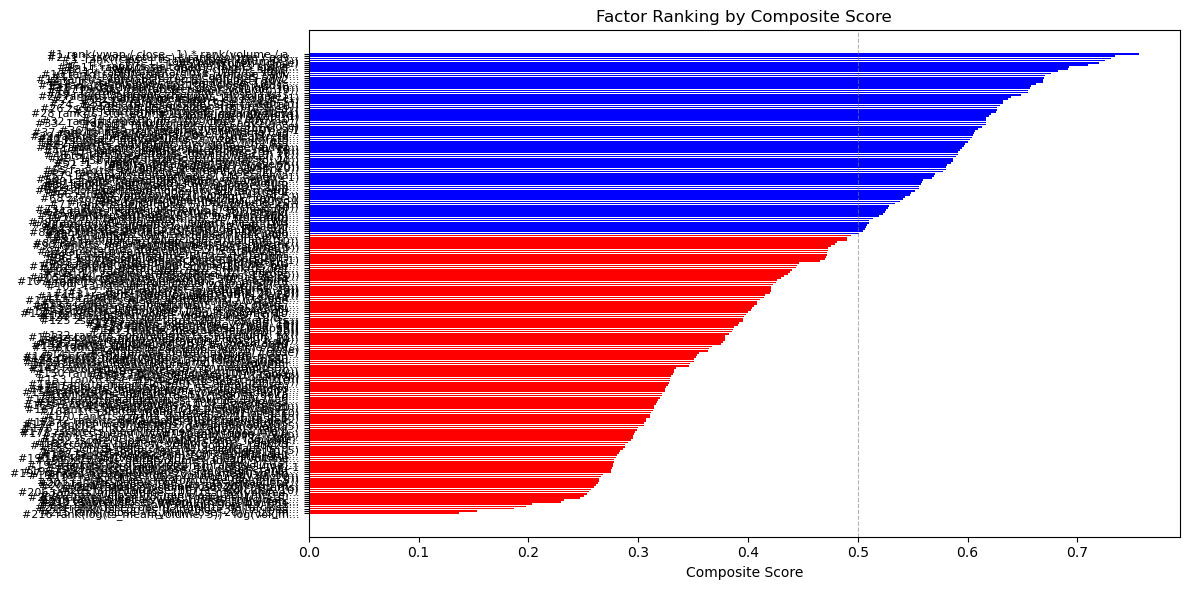

Saved: ../results/plots/plot2_scatter.png


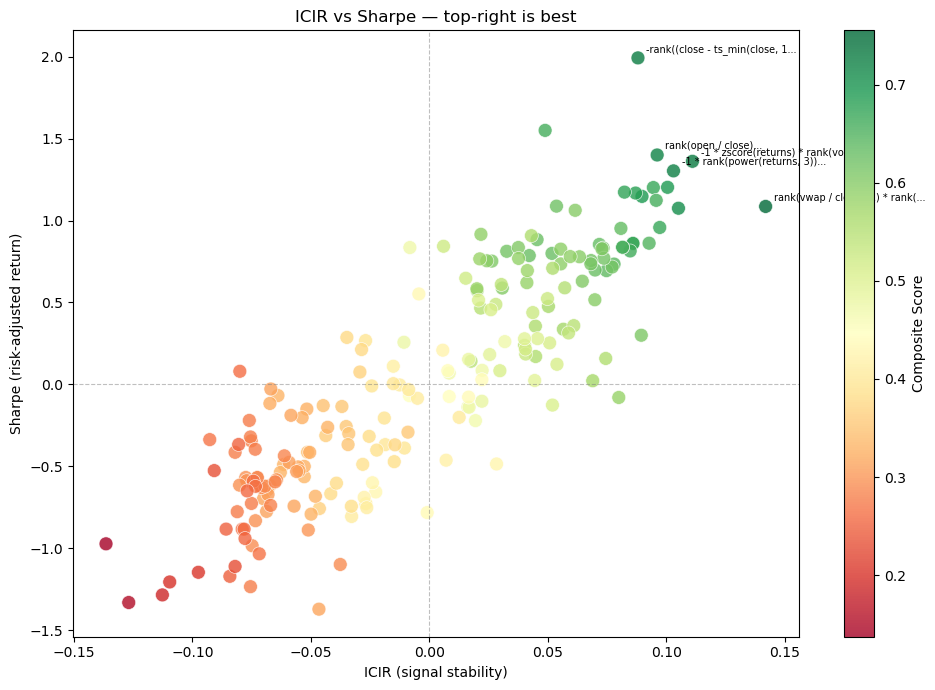

/var/folders/g6/7_gx55l93snbqgq_jbkch3yw0000gn/T/ipykernel_59275/1272580343.py:95: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: ../results/plots/plot3_top_factor.png


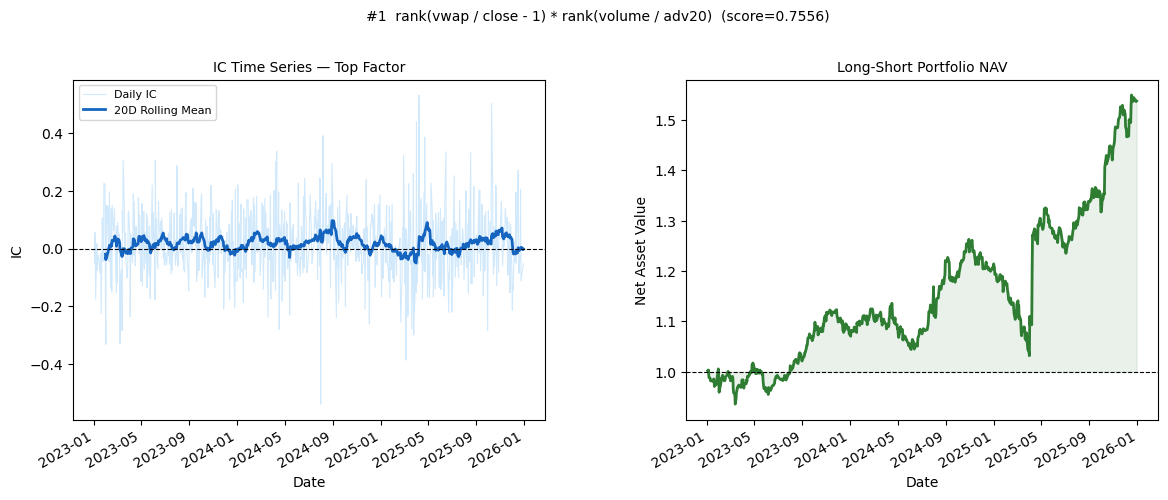

In [11]:
factor_results = compute_all_factors(factors, data)
results        = evaluate_all_factors(factor_results, returns)

plot_score_ranking(results)
plot_icir_vs_sharpe(results)
plot_top_factor_detail(results, factor_results, returns)

In [21]:
top20 = (
    results.sort_values("score", ascending=False)
           .loc[:, ["factor", "score", "IC_mean", "ICIR", "Sharpe", "MDD", "Turnover"]]
           .reset_index(drop=True)
           .head(20)
)

top20.index = top20.index + 1
print(top20)

                                               factor   score  IC_mean  \
1       rank(vwap / close - 1) * rank(volume / adv20)  0.7556   0.0169   
2         -1 * zscore(returns) * rank(volume / adv20)  0.7338   0.0180   
3   -rank((close - ts_min(close, 10)) / (ts_max(cl...  0.7303   0.0145   
4                        -1 * rank(power(returns, 3))  0.7250   0.0179   
5                                  rank(open / close)  0.7194   0.0154   
6   -1 * rank(ts_delta(close, 1) / ts_std(close, 10))  0.7092   0.0168   
7   -1 * rank((close - open) / (high - low + 0.0001))  0.6923   0.0148   
8     -1 * rank((high - low) / close) * sign(returns)  0.6910   0.0148   
9   -1 * rank(ts_delta(close, 10) / ts_std(close, ...  0.6819   0.0145   
10       rank(ts_std(returns, 10) * (volume / adv20))  0.6756   0.0133   
11  -1 * rank((close - ts_mean(close, 5)) / ts_std...  0.6701   0.0159   
12    rank(ts_corr(abs(returns), volume / adv20, 15))  0.6696   0.0083   
13  -1 * sign(close - ts_mean(close, 1

In [20]:
print(type(results))
print(results.columns)
print(results.head())

<class 'pandas.core.frame.DataFrame'>
Index(['IC_mean', 'ICIR', 'Sharpe', 'MDD', 'Turnover', 'factor', 'score'], dtype='object')
      IC_mean    ICIR  Sharpe     MDD  Turnover  \
rank                                              
1      0.0169  0.1420  1.0861 -0.1830    0.7077   
2      0.0180  0.1111  1.3615 -0.1408    0.6850   
3      0.0145  0.0881  1.9927 -0.0730    0.5955   
4      0.0179  0.1031  1.3031 -0.1682    0.7146   
5      0.0154  0.0962  1.4001 -0.1833    0.7119   

                                                 factor   score  
rank                                                             
1         rank(vwap / close - 1) * rank(volume / adv20)  0.7556  
2           -1 * zscore(returns) * rank(volume / adv20)  0.7338  
3     -rank((close - ts_min(close, 10)) / (ts_max(cl...  0.7303  
4                          -1 * rank(power(returns, 3))  0.7250  
5                                    rank(open / close)  0.7194  


## Timing Infrastructure

In [12]:
# Save timing data to CSV
timing_df = pd.DataFrame(list(timing.items()), columns=['function', 'time'])
timing_df.to_csv("../results/timing/opt2_timing.csv", index=False)
print("Timing data saved to ../results/timing/opt2_timing.csv")
print(timing_df)

Timing data saved to ../results/timing/opt2_timing.csv
               function        time
0   compute_all_factors   10.373997
1  evaluate_all_factors  197.347383


## Part X: line_profiler Performance Analysis (Opt2)

Make sure it is installed first: `pip install line_profiler`

Recommended to run in Jupyter first:

- `%load_ext line_profiler`
- Then run the two `%lprun` cells below

**Note**: `line_profiler` adds 3–10× overhead. Trust wall-clock numbers from
the `timing` dict for cross-variant comparison; use `%lprun` only to diagnose
*where* time is spent within a single variant.


In [14]:
# If this is your first use, install in terminal first:
# pip install line_profiler

%load_ext line_profiler


In [ ]:
# 1) Check overall bottleneck: compute_all_factors
%lprun -f compute_all_factors compute_all_factors(factors, data)


In [ ]:
# 2) Check key operators in class internals (rolling corr is often a hotspot)
bt_profile = Opt2Backtester(data)
%lprun -f bt_profile.ts_corr -f bt_profile.compute_factor bt_profile.compute_factor(factors[0]['factor'])
